<a href="https://colab.research.google.com/github/kartik2112/ml-core-concepts/blob/main/notebooks/13_qlora_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QLoRA: Efficient Fine-Tuning of Large Language Models

This notebook covers **QLoRA (Quantized Low-Rank Adaptation)**, a parameter-efficient fine-tuning (PEFT) method that combines 4-bit quantization with LoRA adapters to enable fine-tuning of large language models on consumer hardware.

We'll cover:
1. **Background**: Full fine-tuning vs PEFT vs LoRA
2. **LoRA Math**: Low-rank decomposition theory
3. **QLoRA Innovations**: 4-bit NF4 quantization, double quantization, paged optimizers
4. **Implementation from scratch**: LoRA layers in PyTorch
5. **Practical QLoRA**: Using `transformers`, `peft`, `bitsandbytes`, and `trl`
6. **Training pipeline**: Complete SFT (Supervised Fine-Tuning) workflow
7. **Memory analysis**: How QLoRA reduces VRAM requirements

## Why QLoRA?

| Method | 65B Model Memory | Notes |
|---|---|---|
| Full fine-tuning (fp16) | ~780 GB | Requires many A100s |
| LoRA (fp16) | ~210 GB | Saves optimizer states |
| **QLoRA (4-bit)** | **~48 GB** | **Single A40/A100** |

**Key insight**: Quantize the frozen base model to 4-bit; keep LoRA adapter weights in bf16/fp16.

## 1. Install and Import Libraries

In [1]:
# Install required libraries (run once)
!pip install transformers>=4.40.0 peft>=0.10.0 bitsandbytes>=0.43.0 \
             trl>=0.8.6 datasets>=2.18.0 accelerate>=0.28.0 scipy

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import warnings
from huggingface_hub import login
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

from google.colab import userdata
login(userdata.get('HUGGINGFACE_TOKEN'))

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## 2. LoRA Theory: Low-Rank Decomposition

### The Core Idea

Standard fine-tuning updates every weight matrix $W \in \mathbb{R}^{d \times k}$ in a model. For a 7B parameter model, this is extremely memory-intensive.

**LoRA hypothesis**: Weight updates during fine-tuning lie in a **low-rank subspace**.

Instead of learning $\Delta W$ (same size as $W$), LoRA learns:
$$\Delta W = BA$$

Where:
- $B \in \mathbb{R}^{d \times r}$ — tall matrix
- $A \in \mathbb{R}^{r \times k}$ — wide matrix  
- $r \ll \min(d, k)$ — the **rank** (typically 4, 8, or 16)

**Parameters saved**: Instead of $d \times k$ parameters, we need only $r(d + k)$.

For $d=k=4096, r=16$: Original $\approx 16.7M$, LoRA $\approx 131K$ — **127× reduction!**

### Forward Pass with LoRA
$$h = W_0 x + \Delta W x = W_0 x + \frac{\alpha}{r} BA x$$

Where $\alpha$ is a scaling factor (often $\alpha = r$ making the scaling 1.0).

In [3]:
class LoRALinear(nn.Module):
    """
    A Linear layer augmented with LoRA adapters.

    Forward: h = W_0 x + (alpha/r) * B * A * x
    - W_0 is frozen (pre-trained weights)
    - A and B are trainable low-rank matrices
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        rank: int = 8,
        alpha: float = 16.0,
        dropout: float = 0.05,
        merge_weights: bool = False,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        self.merged = False

        # Frozen pre-trained weight
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.02,
            requires_grad=False  # FROZEN!
        )

        # Trainable LoRA matrices
        # A: initialized with Gaussian, B: initialized to zero
        # This ensures ΔW = BA = 0 at initialization
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.02)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Base model output (frozen)
        base_output = F.linear(x, self.weight)

        # LoRA adapter output: (alpha/r) * B * A * x
        lora_output = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        lora_output = lora_output * self.scaling

        return base_output + lora_output

    def merge_lora_weights(self):
        """Merge LoRA weights into W_0 for faster inference."""
        if not self.merged:
            delta_W = self.scaling * (self.lora_B @ self.lora_A)
            self.weight.data += delta_W
            self.merged = True

    def trainable_parameters(self) -> int:
        return self.lora_A.numel() + self.lora_B.numel()

    def total_parameters(self) -> int:
        return self.weight.numel() + self.trainable_parameters()


# Demonstrate LoRA parameter savings
d_model = 4096
for rank in [4, 8, 16, 32, 64]:
    layer = LoRALinear(d_model, d_model, rank=rank)
    trainable = layer.trainable_parameters()
    total = layer.total_parameters()
    frozen = total - trainable
    pct = 100 * trainable / total
    print(f"rank={rank:3d}: trainable={trainable:8,d} / total={total:12,d} = {pct:.3f}% trainable")

rank=  4: trainable=  32,768 / total=  16,809,984 = 0.195% trainable
rank=  8: trainable=  65,536 / total=  16,842,752 = 0.389% trainable
rank= 16: trainable= 131,072 / total=  16,908,288 = 0.775% trainable
rank= 32: trainable= 262,144 / total=  17,039,360 = 1.538% trainable
rank= 64: trainable= 524,288 / total=  17,301,504 = 3.030% trainable


In [4]:
# Verify LoRA: at initialization ΔW = B*A = 0 (since B=0)
layer = LoRALinear(64, 64, rank=8)
x = torch.randn(4, 64)  # batch of 4

with torch.no_grad():
    base_out = F.linear(x, layer.weight)
    full_out = layer(x)
    diff = (full_out - base_out).abs().max().item()

print(f"Max difference at init (should be ~0): {diff:.2e}")
print(f"✓ ΔW = BA is zero at initialization — training starts from pre-trained behavior")

# Verify gradient flow: only A and B receive gradients
out = layer(x).sum()
out.backward()

print(f"\nGradient check:")
print(f"  weight.grad is None (frozen): {layer.weight.grad is None}")
print(f"  lora_A.grad is not None: {layer.lora_A.grad is not None}")
print(f"  lora_B.grad is not None: {layer.lora_B.grad is not None}")

Max difference at init (should be ~0): 0.00e+00
✓ ΔW = BA is zero at initialization — training starts from pre-trained behavior

Gradient check:
  weight.grad is None (frozen): True
  lora_A.grad is not None: True
  lora_B.grad is not None: True


## 3. Which Layers to Apply LoRA?

In transformer models, LoRA is typically applied to attention projection matrices:
- `q_proj`, `k_proj`, `v_proj`, `o_proj` (attention)
- `gate_proj`, `up_proj`, `down_proj` (MLP/FFN, optional)

The paper found that applying LoRA to **all attention layers** works best.

In [5]:
class LoRATransformerBlock(nn.Module):
    """
    Simplified transformer block with LoRA applied to Q, K, V, O projections.
    """

    def __init__(self, d_model: int, n_heads: int, rank: int = 8, alpha: float = 16.0):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # Attention projections with LoRA
        self.q_proj = LoRALinear(d_model, d_model, rank=rank, alpha=alpha)
        self.k_proj = LoRALinear(d_model, d_model, rank=rank, alpha=alpha)
        self.v_proj = LoRALinear(d_model, d_model, rank=rank, alpha=alpha)
        self.o_proj = LoRALinear(d_model, d_model, rank=rank, alpha=alpha)

        # FFN layers (frozen, no LoRA in this example)
        self.ffn_up = nn.Linear(d_model, 4 * d_model)
        self.ffn_down = nn.Linear(4 * d_model, d_model)
        for p in list(self.ffn_up.parameters()) + list(self.ffn_down.parameters()):
            p.requires_grad = False

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape

        # Self-attention with LoRA
        x_norm = self.norm1(x)
        Q = self.q_proj(x_norm).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x_norm).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x_norm).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scale = math.sqrt(self.head_dim)
        attn = torch.softmax(Q @ K.transpose(-2, -1) / scale, dim=-1)
        attn_out = (attn @ V).transpose(1, 2).reshape(B, T, C)
        x = x + self.o_proj(attn_out)

        # FFN (frozen)
        x = x + self.ffn_down(F.relu(self.ffn_up(self.norm2(x))))
        return x

    def count_parameters(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total


block = LoRATransformerBlock(d_model=512, n_heads=8, rank=8)
trainable, total = block.count_parameters()
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print(f"% Trainable:          {100*trainable/total:.2f}%")

# Forward pass test
x_test = torch.randn(2, 32, 512)  # (batch, seq_len, d_model)
out_test = block(x_test)
print(f"\nForward pass: {x_test.shape} -> {out_test.shape} ✓")

Trainable parameters: 34,816
Total parameters:     3,183,104
% Trainable:          1.09%

Forward pass: torch.Size([2, 32, 512]) -> torch.Size([2, 32, 512]) ✓


## 4. QLoRA Innovations: Beyond LoRA

QLoRA adds three key innovations on top of LoRA:

### 4.1 NF4 (NormalFloat4) Quantization

Standard 4-bit quantization uses uniform bins. NF4 uses **information-theoretically optimal** bins for normally distributed weights.

NF4 quantile levels are computed from $q_i = \frac{1}{2} \left( Q_X \left(\frac{i}{2^k+1}\right) + Q_X \left(\frac{i+1}{2^k+1}\right) \right)$

### 4.2 Double Quantization

Also quantize the quantization constants themselves:
- Block quantization: group 64 weights, store one scale per block
- Double quant: quantize those scales too (FP8 → saves ~0.37 bits/param)

### 4.3 Paged Optimizers

Use NVIDIA's unified memory to page optimizer states between GPU and CPU RAM, preventing OOM during training spikes.

In [6]:
def compute_nf4_levels(num_bits: int = 4) -> np.ndarray:
    """
    Compute NormalFloat quantization levels.
    These are evenly-spaced quantiles of the standard normal distribution.
    """
    from scipy import stats
    n = 2 ** num_bits  # 16 for 4-bit
    # Compute quantile values for a standard normal
    quantiles = [(i + 0.5) / n for i in range(n)]
    levels = stats.norm.ppf(quantiles)  # inverse CDF
    # Normalize to [-1, 1]
    levels = levels / max(abs(levels.min()), abs(levels.max()))
    return levels

def quantize_to_nf4(weights: np.ndarray, levels: np.ndarray) -> tuple:
    """
    Quantize a weight tensor to NF4 format.

    Returns: (quantized indices, scale factor)
    """
    # Normalize to [-1, 1] using absmax
    scale = np.abs(weights).max()
    if scale == 0:
        return np.zeros_like(weights, dtype=np.int8), 1.0
    normalized = weights / scale

    # Find nearest NF4 level for each weight
    indices = np.array([
        np.argmin(np.abs(levels - w)) for w in normalized.flatten()
    ]).reshape(weights.shape).astype(np.int8)

    return indices, scale

def dequantize_from_nf4(indices: np.ndarray, scale: float, levels: np.ndarray) -> np.ndarray:
    """Reconstruct weights from NF4 format."""
    return levels[indices] * scale


# Compare uniform vs NF4 quantization error on normally distributed weights
nf4_levels = compute_nf4_levels(num_bits=4)
uniform_levels = np.linspace(-1, 1, 16)  # standard 4-bit uniform

# Generate normally distributed weights (typical LLM weight distribution)
weights = np.random.randn(10000) * 0.02  # typical LLM weight std

# Quantize and compute errors
nf4_idx, nf4_scale = quantize_to_nf4(weights, nf4_levels)
nf4_recon = dequantize_from_nf4(nf4_idx, nf4_scale, nf4_levels)
nf4_error = np.mean((weights - nf4_recon)**2)

uniform_idx, uniform_scale = quantize_to_nf4(weights, uniform_levels)
uniform_recon = dequantize_from_nf4(uniform_idx, uniform_scale, uniform_levels)
uniform_error = np.mean((weights - uniform_recon)**2)

print(f"Quantization MSE comparison (4-bit, 10K normally-distributed weights):")
print(f"  Uniform 4-bit: {uniform_error:.2e}")
print(f"  NF4:           {nf4_error:.2e}")
print(f"  Improvement:   {uniform_error/nf4_error:.1f}x lower error with NF4")

Quantization MSE comparison (4-bit, 10K normally-distributed weights):
  Uniform 4-bit: 9.25e-06
  NF4:           4.87e-06
  Improvement:   1.9x lower error with NF4


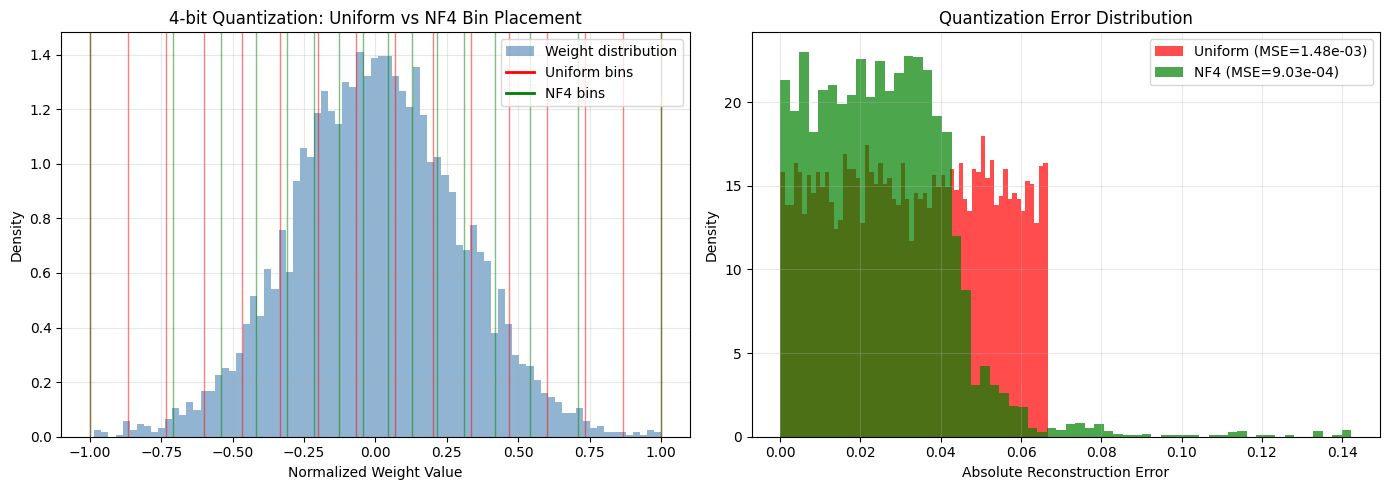

NF4 places more bins near 0 (where most weights cluster) → lower reconstruction error


In [7]:
# Visualize NF4 vs uniform quantization bin placement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample weights from normal distribution
sample_weights = np.random.randn(5000) * 0.02
normalized_weights = sample_weights / np.abs(sample_weights).max()

# Plot 1: Bin placement comparison
ax = axes[0]
ax.hist(normalized_weights, bins=80, density=True, alpha=0.6, color='steelblue', label='Weight distribution')

for level in uniform_levels:
    ax.axvline(level, color='red', alpha=0.5, linewidth=1)
for level in nf4_levels:
    ax.axvline(level, color='green', alpha=0.5, linewidth=1)

ax.plot([], [], color='red', linewidth=2, label='Uniform bins')
ax.plot([], [], color='green', linewidth=2, label='NF4 bins')
ax.set_xlabel('Normalized Weight Value')
ax.set_ylabel('Density')
ax.set_title('4-bit Quantization: Uniform vs NF4 Bin Placement')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Reconstruction error distribution
ax = axes[1]
nf4_errors = np.abs(normalized_weights - dequantize_from_nf4(
    np.array([np.argmin(np.abs(nf4_levels - w)) for w in normalized_weights], dtype=np.int8),
    1.0, nf4_levels
))
uniform_errors = np.abs(normalized_weights - dequantize_from_nf4(
    np.array([np.argmin(np.abs(uniform_levels - w)) for w in normalized_weights], dtype=np.int8),
    1.0, uniform_levels
))

ax.hist(uniform_errors, bins=60, alpha=0.7, color='red', label=f'Uniform (MSE={np.mean(uniform_errors**2):.2e})', density=True)
ax.hist(nf4_errors, bins=60, alpha=0.7, color='green', label=f'NF4 (MSE={np.mean(nf4_errors**2):.2e})', density=True)
ax.set_xlabel('Absolute Reconstruction Error')
ax.set_ylabel('Density')
ax.set_title('Quantization Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nf4_vs_uniform_quantization.png', dpi=100, bbox_inches='tight')
plt.show()
print("NF4 places more bins near 0 (where most weights cluster) → lower reconstruction error")

## 5. Memory Analysis: Why QLoRA Is So Efficient

Let's analyze memory requirements across different fine-tuning strategies.

In [8]:
def estimate_memory_gb(num_params_B: float, method: str) -> dict:
    """
    Estimate GPU memory for different fine-tuning approaches.

    Args:
        num_params_B: Number of parameters in billions
        method: 'full_fp32', 'full_fp16', 'lora_fp16', 'qlora_4bit'
    """
    P = num_params_B * 1e9
    lora_ratio = 0.01  # ~1% of params as LoRA adapters
    P_lora = P * lora_ratio

    results = {}

    if method == 'full_fp32':
        weights = P * 4       # 4 bytes per param (fp32)
        grads = P * 4         # same size as weights
        optimizer = P * 8     # Adam: 2 momentum terms × 4 bytes
        activations = P * 2   # rough estimate
    elif method == 'full_fp16':
        weights = P * 2       # 2 bytes (fp16)
        grads = P * 2
        optimizer = P * 8     # Adam fp32 master copy + momentums
        activations = P * 1
    elif method == 'lora_fp16':
        weights = P * 2       # frozen weights in fp16
        grads = P_lora * 2    # only adapter grads
        optimizer = P_lora * 8 # Adam for adapters only
        activations = P * 1
    elif method == 'qlora_4bit':
        weights = P * 0.5     # 4-bit = 0.5 bytes per param
        grads = P_lora * 2    # bf16 adapter grads
        optimizer = P_lora * 8 # paged Adam for adapters
        activations = P * 0.25 # less activation memory (gradient checkpointing)

    total = weights + grads + optimizer + activations
    results = {
        'weights_GB': weights / 1e9,
        'gradients_GB': grads / 1e9,
        'optimizer_GB': optimizer / 1e9,
        'activations_GB': activations / 1e9,
        'total_GB': total / 1e9,
    }
    return results


# Compare methods for common model sizes
model_sizes = [7, 13, 34, 65]  # billions of parameters
methods = ['full_fp32', 'full_fp16', 'lora_fp16', 'qlora_4bit']
method_labels = ['Full FP32', 'Full FP16', 'LoRA FP16', 'QLoRA 4-bit']
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

print(f"{'Model':>8}  {'Full FP32':>12} {'Full FP16':>12} {'LoRA FP16':>12} {'QLoRA 4-bit':>12}")
print("-" * 60)
for size in model_sizes:
    row = f"{size}B params"
    for method in methods:
        mem = estimate_memory_gb(size, method)['total_GB']
        row += f"  {mem:>10.1f}GB"
    print(row)

   Model     Full FP32    Full FP16    LoRA FP16  QLoRA 4-bit
------------------------------------------------------------
7B params       126.0GB        91.0GB        21.7GB         6.0GB
13B params       234.0GB       169.0GB        40.3GB        11.1GB
34B params       612.0GB       442.0GB       105.4GB        28.9GB
65B params      1170.0GB       845.0GB       201.5GB        55.2GB


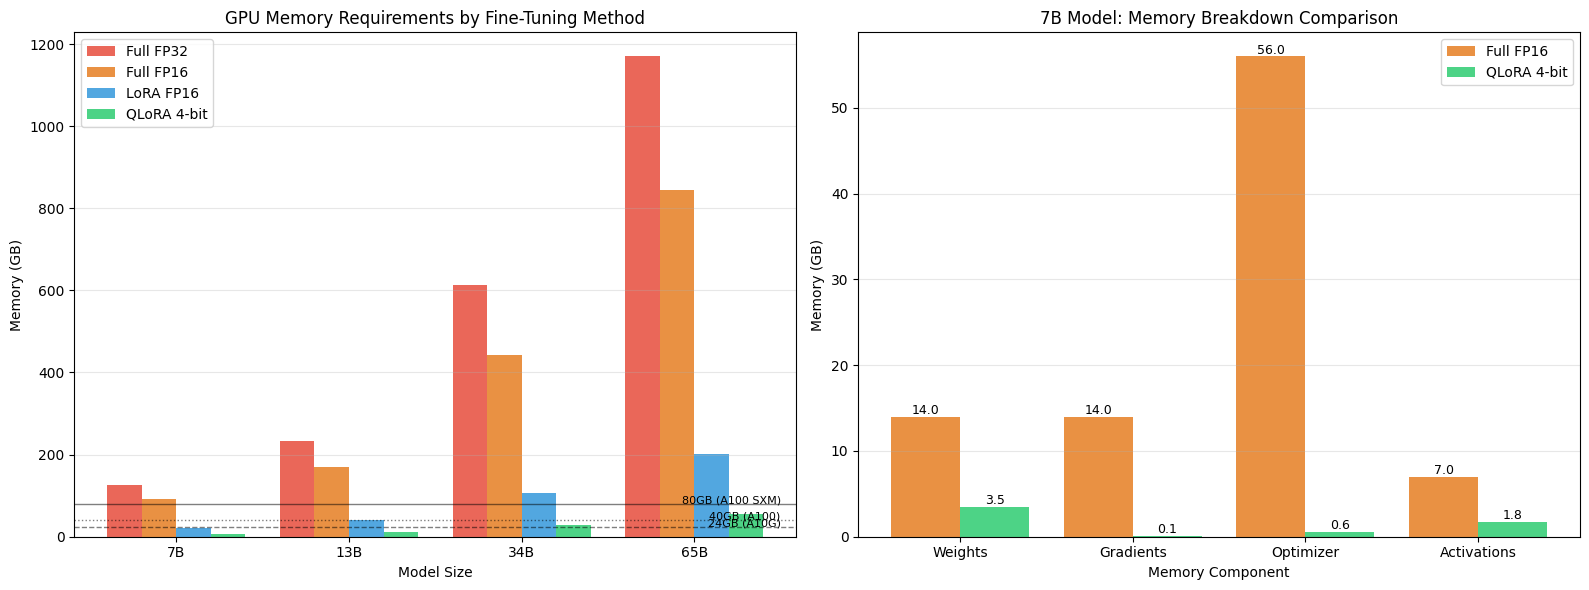

In [9]:
# Visualize memory requirements
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total memory by model size and method
ax = axes[0]
x = np.arange(len(model_sizes))
width = 0.2

for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
    totals = [estimate_memory_gb(s, method)['total_GB'] for s in model_sizes]
    ax.bar(x + i * width, totals, width, label=label, color=color, alpha=0.85)

# GPU memory references
for mem, name, ls in [(24, '24GB (A10G)', '--'), (40, '40GB (A100)', ':'), (80, '80GB (A100 SXM)', '-')]:
    ax.axhline(mem, linestyle=ls, color='black', alpha=0.5, linewidth=1)
    ax.text(3.8, mem + 1, name, ha='right', fontsize=8, color='black')

ax.set_xlabel('Model Size')
ax.set_ylabel('Memory (GB)')
ax.set_title('GPU Memory Requirements by Fine-Tuning Method')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([f'{s}B' for s in model_sizes])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Memory breakdown for 7B model with QLoRA
ax = axes[1]
qlora_breakdown = estimate_memory_gb(7, 'qlora_4bit')
fp16_breakdown = estimate_memory_gb(7, 'full_fp16')

categories = ['Weights', 'Gradients', 'Optimizer', 'Activations']
keys = ['weights_GB', 'gradients_GB', 'optimizer_GB', 'activations_GB']

x_pos = np.arange(len(categories))
qlora_vals = [qlora_breakdown[k] for k in keys]
fp16_vals = [fp16_breakdown[k] for k in keys]

ax.bar(x_pos - 0.2, fp16_vals, 0.4, label='Full FP16', color='#e67e22', alpha=0.85)
ax.bar(x_pos + 0.2, qlora_vals, 0.4, label='QLoRA 4-bit', color='#2ecc71', alpha=0.85)

ax.set_xlabel('Memory Component')
ax.set_ylabel('Memory (GB)')
ax.set_title('7B Model: Memory Breakdown Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (fp16, qlora) in enumerate(zip(fp16_vals, qlora_vals)):
    ax.text(i - 0.2, fp16 + 0.3, f'{fp16:.1f}', ha='center', fontsize=9)
    ax.text(i + 0.2, qlora + 0.3, f'{qlora:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('qlora_memory_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Practical QLoRA with Hugging Face Libraries

Now let's implement a complete QLoRA fine-tuning pipeline using:
- `transformers` — model and tokenizer
- `peft` — LoRA configuration
- `bitsandbytes` — 4-bit quantization
- `trl` — `SFTTrainer` for supervised fine-tuning
- `datasets` — dataset loading

In [10]:
# Check if libraries are available
try:
    import transformers
    import peft
    import trl
    import datasets
    LIBS_AVAILABLE = True
    print(f"transformers: {transformers.__version__}")
    print(f"peft:         {peft.__version__}")
    print(f"trl:          {trl.__version__}")
    print(f"datasets:     {datasets.__version__}")
    try:
        import bitsandbytes as bnb
        print(f"bitsandbytes: {bnb.__version__}")
        BNB_AVAILABLE = True
    except ImportError:
        print("bitsandbytes: not installed (required for 4-bit quantization on GPU)")
        BNB_AVAILABLE = False
except ImportError as e:
    LIBS_AVAILABLE = False
    BNB_AVAILABLE = False
    print(f"Libraries not available: {e}")
    print("Install with: pip install transformers peft bitsandbytes trl datasets accelerate")

transformers: 5.0.0
peft:         0.18.1
trl:          0.29.0
datasets:     4.0.0
bitsandbytes: 0.49.2


In [11]:
# ============================================================
# QLoRA Configuration
# ============================================================

# Model configuration
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"  # Use small model for demo
# For production: "meta-llama/Llama-3.1-8B-Instruct", "mistralai/Mistral-7B-Instruct-v0.3"

# Dataset configuration
DATASET_NAME = "timdettmers/openassistant-guanaco"  # Instruction-following dataset
# Other good datasets: "HuggingFaceH4/ultrachat_200k", "teknium/OpenHermes-2.5"

# LoRA configuration
LORA_CONFIG = {
    "r": 16,                    # LoRA rank (4, 8, 16, 32, 64)
    "lora_alpha": 32,           # Scaling factor (usually 2×rank)
    "target_modules": [         # Which modules to apply LoRA to
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    "lora_dropout": 0.05,       # Dropout on LoRA layers
    "bias": "none",             # Don't train bias terms
    "task_type": "CAUSAL_LM",   # Task type for PEFT
}

# 4-bit quantization configuration
QUANTIZATION_CONFIG = {
    "load_in_4bit": True,
    "bnb_4bit_compute_dtype": "bfloat16",  # Compute in bf16 for stability
    "bnb_4bit_use_double_quant": True,      # Double quantization for extra savings
    "bnb_4bit_quant_type": "nf4",           # NormalFloat4 quantization
    "bnb_4bit_quant_storage": "uint8",      # Storage dtype
}

# Training configuration
TRAINING_CONFIG = {
    "output_dir": "./qlora-output",
    "num_train_epochs": 1,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 4,      # Effective batch = 4×4=16
    "gradient_checkpointing": True,         # Save activation memory
    "optim": "paged_adamw_32bit",           # Paged optimizer (QLoRA innovation)
    "learning_rate": 2e-4,
    "weight_decay": 0.001,
    "fp16": False,
    "bf16": True,                           # Train adapters in bf16
    "max_grad_norm": 0.3,
    "warmup_ratio": 0.03,
    "lr_scheduler_type": "cosine",
    "logging_steps": 25,
    "save_steps": 100,
    "max_steps": 200,                       # Limit for demo
    "report_to": "none",                    # Disable wandb for demo
}

# SFT-specific configuration
SFT_CONFIG = {
    "max_seq_length": 1024,
    "dataset_text_field": "text",           # Column name in dataset
    "packing": True,                        # Pack multiple short sequences together
}

print("QLoRA Configuration:")
print(f"  Model:          {MODEL_NAME}")
print(f"  Dataset:        {DATASET_NAME}")
print(f"  LoRA rank:      {LORA_CONFIG['r']}")
print(f"  Quant type:     {QUANTIZATION_CONFIG['bnb_4bit_quant_type']}")
print(f"  Compute dtype:  {QUANTIZATION_CONFIG['bnb_4bit_compute_dtype']}")
print(f"  Double quant:   {QUANTIZATION_CONFIG['bnb_4bit_use_double_quant']}")

QLoRA Configuration:
  Model:          meta-llama/Llama-3.2-1B-Instruct
  Dataset:        timdettmers/openassistant-guanaco
  LoRA rank:      16
  Quant type:     nf4
  Compute dtype:  bfloat16
  Double quant:   True


In [13]:
# ============================================================
# Full QLoRA Training Pipeline
# ============================================================
# NOTE: This requires a GPU with sufficient VRAM.
# The LLaMA 3.2 1B model in 4-bit needs ~2-3GB VRAM.
# Uncomment and run on a GPU-enabled machine.
# ============================================================

def train_with_qlora(
    model_name: str = MODEL_NAME,
    dataset_name: str = DATASET_NAME,
):
    """
    Complete QLoRA fine-tuning pipeline.
    """
    from transformers import (
        AutoModelForCausalLM,
        AutoTokenizer,
        BitsAndBytesConfig,
    )
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    from trl import SFTTrainer, SFTConfig
    from datasets import load_dataset
    import torch

    # Step 1: Configure 4-bit quantization
    print("Step 1: Setting up 4-bit quantization config...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=QUANTIZATION_CONFIG["load_in_4bit"],
        bnb_4bit_compute_dtype=getattr(torch, QUANTIZATION_CONFIG["bnb_4bit_compute_dtype"]),
        bnb_4bit_use_double_quant=QUANTIZATION_CONFIG["bnb_4bit_use_double_quant"],
        bnb_4bit_quant_type=QUANTIZATION_CONFIG["bnb_4bit_quant_type"],
    )

    # Step 2: Load quantized base model
    print(f"Step 2: Loading model '{model_name}' in 4-bit...")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",          # Automatically spread across available GPUs
        torch_dtype=torch.bfloat16,
        trust_remote_code=True,
    )

    # Step 3: Prepare model for k-bit training
    # This: (1) casts LayerNorm to fp32, (2) makes output embedding require grad,
    # (3) upcasts LM head to fp32
    print("Step 3: Preparing model for k-bit training...")
    model = prepare_model_for_kbit_training(
        model,
        use_gradient_checkpointing=TRAINING_CONFIG["gradient_checkpointing"],
    )

    # Step 4: Load tokenizer
    print("Step 4: Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token  # LLaMA has no pad token
    tokenizer.padding_side = "right"            # Prevents warnings

    # Step 5: Configure LoRA
    print("Step 5: Configuring LoRA adapters...")
    lora_config = LoraConfig(
        r=LORA_CONFIG["r"],
        lora_alpha=LORA_CONFIG["lora_alpha"],
        target_modules=LORA_CONFIG["target_modules"],
        lora_dropout=LORA_CONFIG["lora_dropout"],
        bias=LORA_CONFIG["bias"],
        task_type=LORA_CONFIG["task_type"],
    )

    # Wrap model with PEFT (adds LoRA adapters)
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # Step 6: Load dataset
    print(f"Step 6: Loading dataset '{dataset_name}'...")
    dataset = load_dataset(dataset_name, split="train")
    print(f"  Dataset size: {len(dataset)} examples")

    # Step 7: Configure SFT training
    print("Step 7: Setting up SFT trainer...")
    sft_config = SFTConfig(
        output_dir=TRAINING_CONFIG["output_dir"],
        num_train_epochs=TRAINING_CONFIG["num_train_epochs"],
        per_device_train_batch_size=TRAINING_CONFIG["per_device_train_batch_size"],
        gradient_accumulation_steps=TRAINING_CONFIG["gradient_accumulation_steps"],
        gradient_checkpointing=TRAINING_CONFIG["gradient_checkpointing"],
        optim=TRAINING_CONFIG["optim"],
        learning_rate=TRAINING_CONFIG["learning_rate"],
        weight_decay=TRAINING_CONFIG["weight_decay"],
        bf16=TRAINING_CONFIG["bf16"],
        max_grad_norm=TRAINING_CONFIG["max_grad_norm"],
        warmup_ratio=TRAINING_CONFIG["warmup_ratio"],
        lr_scheduler_type=TRAINING_CONFIG["lr_scheduler_type"],
        logging_steps=TRAINING_CONFIG["logging_steps"],
        save_steps=TRAINING_CONFIG["save_steps"],
        max_steps=TRAINING_CONFIG["max_steps"],
        report_to=TRAINING_CONFIG["report_to"],
        max_length=SFT_CONFIG["max_seq_length"],
        dataset_text_field=SFT_CONFIG["dataset_text_field"],
        packing=SFT_CONFIG["packing"],
    )

    trainer = SFTTrainer(
        model=model,
        args=sft_config,
        train_dataset=dataset,
        processing_class=tokenizer,
    )

    # Step 8: Train!
    print("Step 8: Starting training...")
    trainer.train()

    # Step 9: Save the adapter weights (NOT the full model)
    print("Step 9: Saving LoRA adapter weights...")
    trainer.save_model()
    tokenizer.save_pretrained(TRAINING_CONFIG["output_dir"])

    print("✓ QLoRA fine-tuning complete!")
    return model, tokenizer


# Uncomment to run training (requires GPU + HuggingFace model access):
model, tokenizer = train_with_qlora()

# print("QLoRA training function defined.")
# print("To run: uncomment the last line above (requires GPU).")

Step 1: Setting up 4-bit quantization config...
Step 2: Loading model 'meta-llama/Llama-3.2-1B-Instruct' in 4-bit...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Step 3: Preparing model for k-bit training...
Step 4: Loading tokenizer...
Step 5: Configuring LoRA adapters...
trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039
Step 6: Loading dataset 'timdettmers/openassistant-guanaco'...


Repo card metadata block was not found. Setting CardData to empty.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Dataset size: 9846 examples
Step 7: Setting up SFT trainer...


...

Packing train dataset:   0%|          | 0/9846 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step 8: Starting training...


Step,Training Loss
25,1.857250
50,1.652754
75,1.655556
100,1.658898
125,1.665109
150,1.673928
175,1.648512
200,1.658512


Step 9: Saving LoRA adapter weights...
✓ QLoRA fine-tuning complete!
QLoRA training function defined.
To run: uncomment the last line above (requires GPU).


## 7. Loading and Merging LoRA Weights for Inference

In [14]:
def load_qlora_for_inference(base_model_name: str, adapter_path: str, merge: bool = False):
    """
    Load a QLoRA-trained model for inference.

    Two options:
    1. merge=False: Load base model + attach adapter (memory efficient, slightly slower)
    2. merge=True:  Merge adapter into base model (faster inference, more memory)
    """
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from peft import PeftModel
    import torch

    tokenizer = AutoTokenizer.from_pretrained(base_model_name)

    if not merge:
        # Option 1: Load quantized model + adapter (recommended for deployment)
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_quant_type="nf4",
        )
        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            quantization_config=bnb_config,
            device_map="auto",
        )
        model = PeftModel.from_pretrained(base_model, adapter_path)
    else:
        # Option 2: Merge and unload adapters (full precision, faster inference)
        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
        model = PeftModel.from_pretrained(base_model, adapter_path)
        model = model.merge_and_unload()  # Merges ΔW = BA into W_0

    return model, tokenizer


def generate_response(model, tokenizer, prompt: str, max_new_tokens: int = 256) -> str:
    """Generate a response from the fine-tuned model."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the new tokens (not the prompt)
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


print("Inference functions defined.")
print("\nUsage after training:")
print("  model, tok = load_qlora_for_inference('meta-llama/Llama-3.2-1B-Instruct', './qlora-output')")
print("  response = generate_response(model, tok, 'What is machine learning?')")

Inference functions defined.

Usage after training:
  model, tok = load_qlora_for_inference('meta-llama/Llama-3.2-1B-Instruct', './qlora-output')
  response = generate_response(model, tok, 'What is machine learning?')


## 8. LoRA Rank Selection: Ablation Study Simulation

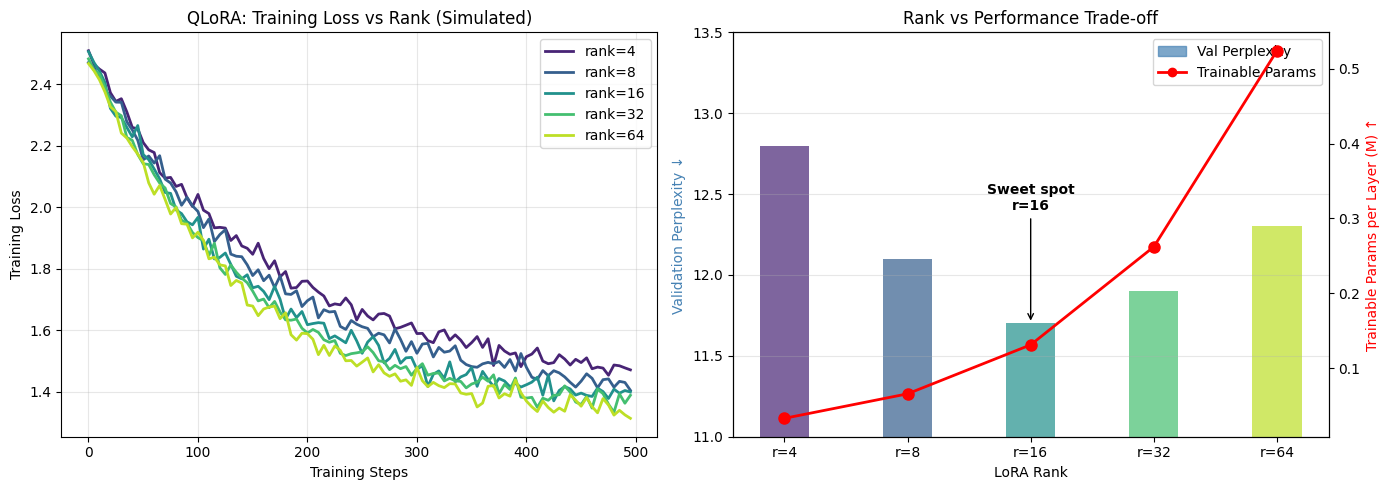

In [15]:
# Simulate how rank affects training dynamics and performance
# (Based on typical results from the LoRA/QLoRA papers)
np.random.seed(42)

ranks = [4, 8, 16, 32, 64]
steps = np.arange(0, 500, 5)

# Simulate training loss curves for different ranks
# Higher rank → can overfit more → lower train loss, but potentially worse generalization
def simulate_loss(steps, final_loss, convergence_speed, noise=0.02):
    loss = final_loss + (2.5 - final_loss) * np.exp(-convergence_speed * steps / 500)
    loss += np.random.randn(len(steps)) * noise
    return np.maximum(loss, final_loss * 0.8)

rank_params = {
    4:  {'final_loss': 1.42, 'speed': 3.0, 'val_perplexity': 12.8},
    8:  {'final_loss': 1.38, 'speed': 3.2, 'val_perplexity': 12.1},
    16: {'final_loss': 1.35, 'speed': 3.5, 'val_perplexity': 11.7},
    32: {'final_loss': 1.33, 'speed': 3.6, 'val_perplexity': 11.9},
    64: {'final_loss': 1.31, 'speed': 3.7, 'val_perplexity': 12.3},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training loss curves
ax = axes[0]
colors_rank = plt.cm.viridis(np.linspace(0.1, 0.9, len(ranks)))
for rank, color in zip(ranks, colors_rank):
    p = rank_params[rank]
    loss = simulate_loss(steps, p['final_loss'], p['speed'])
    ax.plot(steps, loss, color=color, label=f'rank={rank}', linewidth=2)

ax.set_xlabel('Training Steps')
ax.set_ylabel('Training Loss')
ax.set_title('QLoRA: Training Loss vs Rank (Simulated)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Validation perplexity and trainable parameters vs rank
ax = axes[1]
perplexities = [rank_params[r]['val_perplexity'] for r in ranks]
trainable_params = [2 * r * 4096 / 1e6 for r in ranks]  # ~per layer in millions

ax2 = ax.twinx()
bars = ax.bar(range(len(ranks)), perplexities, color=colors_rank, alpha=0.7, width=0.4, label='Val Perplexity')
line, = ax2.plot(range(len(ranks)), trainable_params, 'ro-', linewidth=2, markersize=8, label='Trainable Params')

ax.set_xlabel('LoRA Rank')
ax.set_ylabel('Validation Perplexity ↓', color='steelblue')
ax2.set_ylabel('Trainable Params per Layer (M) ↑', color='red')
ax.set_title('Rank vs Performance Trade-off')
ax.set_xticks(range(len(ranks)))
ax.set_xticklabels([f'r={r}' for r in ranks])
ax.set_ylim([11, 13.5])

lines = [mpatches.Patch(color='steelblue', alpha=0.7, label='Val Perplexity'),
         plt.Line2D([0], [0], color='red', marker='o', linewidth=2, label='Trainable Params')]
ax.legend(handles=lines, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

ax.annotate('Sweet spot\nr=16', xy=(2, 11.7), xytext=(2, 12.4),
            arrowprops=dict(arrowstyle='->', color='black'),
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('qlora_rank_ablation.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Summary

### QLoRA Key Concepts

| Component | What It Does | Why It Matters |
|---|---|---|
| **NF4 quantization** | Store weights in 4-bit NormalFloat | 8× memory reduction vs fp32 |
| **Double quantization** | Quantize the quantization constants | Saves ~0.37 bits/param extra |
| **LoRA adapters** | Low-rank trainable matrices $\Delta W = BA$ | Only 0.1-1% of params are trained |
| **Paged optimizers** | CPU-GPU memory paging for Adam states | Prevents OOM during gradient spikes |
| **Gradient checkpointing** | Recompute activations vs storing them | Trade compute for memory |

### LoRA Hyperparameter Guidelines

| Parameter | Recommended | Effect |
|---|---|---|
| Rank `r` | 8-16 | Higher = more expressive but more params |
| Alpha `α` | `2 × r` | Scaling: larger = larger update magnitude |
| Dropout | 0.05 | Regularization |
| Target modules | Q, K, V, O, FFN | More modules = better but more params |
| Learning rate | 1e-4 to 3e-4 | Higher than full fine-tuning |

### When to Use QLoRA

✅ **Use QLoRA when:**
- Fine-tuning models > 7B parameters
- Limited GPU memory (< 40GB)
- Multiple task-specific adapters needed (swap adapters cheaply)
- Quick iteration on different datasets

❌ **Consider full fine-tuning when:**
- Task requires significant distribution shift from pre-training
- Maximum performance at any cost
- Small models (< 1B) where full FT is feasible

### Next Steps
- **DPO** (Notebook 14): Align the SFT model using preference data
- **PPO/RLHF** (Notebook 15): Train with a reward model and proximal policy optimization